In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="white", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

TREATED_COLOR = "#c0392b"
CONTROL_COLOR = "#1a2744"
MERGER_COLOR  = "#7f8c8d"

FIG_DIR = Path("../docs/figures/proposal")
FIG_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_parquet("../data/processed/panel.parquet")
print(f"Panel loaded: {panel.shape}")
print(f"Treated routes: {panel[panel['treated']==1]['route'].nunique()}")
print(f"Control routes: {panel[panel['treated']==0]['route'].nunique()}")

Panel loaded: (122787, 25)
Treated routes: 1223
Control routes: 3721


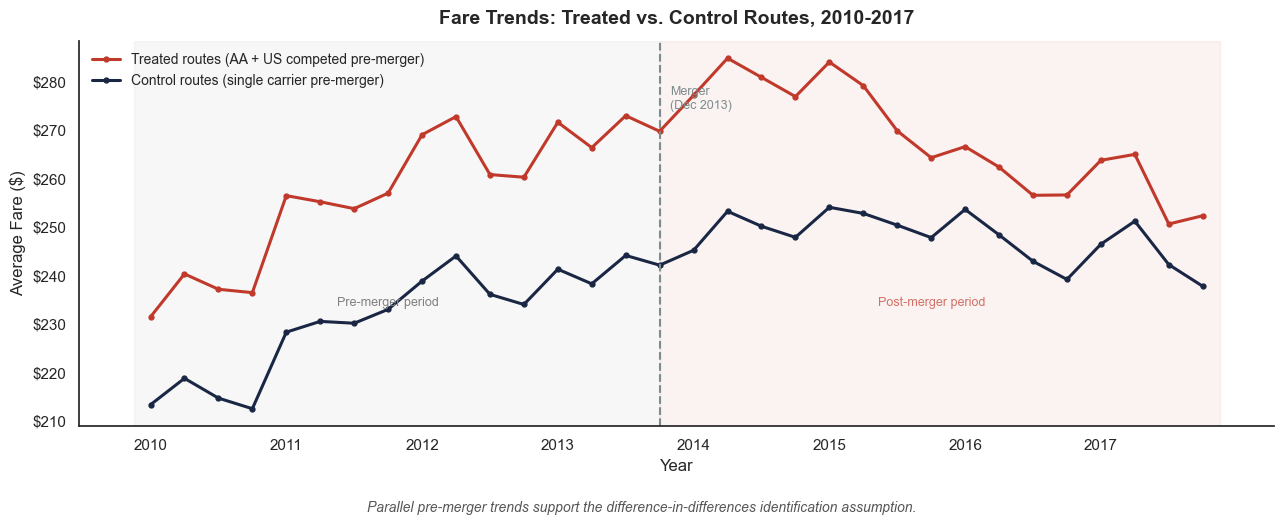

Saved: parallel_trends.png


In [2]:
trends = (
    panel.groupby(["quarter_idx", "treated"])["avg_fare"]
    .mean().reset_index()
)
treated_trend = trends[trends["treated"] == 1].set_index("quarter_idx")["avg_fare"]
control_trend = trends[trends["treated"] == 0].set_index("quarter_idx")["avg_fare"]

xtick_positions = [i for i in sorted(trends["quarter_idx"].unique()) if i % 4 == 0]
xtick_labels = [str(2010 + i // 4) for i in xtick_positions]

fig, ax = plt.subplots(figsize=(13, 5))

ax.axvspan(-0.5, 15, alpha=0.06, color="grey")
ax.axvspan(15, 31.5, alpha=0.06, color=TREATED_COLOR)

ax.plot(treated_trend.index, treated_trend.values,
        color=TREATED_COLOR, linewidth=2.2, marker="o", markersize=3.5,
        label="Treated routes (AA + US competed pre-merger)")
ax.plot(control_trend.index, control_trend.values,
        color=CONTROL_COLOR, linewidth=2.2, marker="o", markersize=3.5,
        label="Control routes (single carrier pre-merger)")

ax.axvline(15, color=MERGER_COLOR, linestyle="--", linewidth=1.5)
ax.text(15.3, treated_trend.max() * 0.98, "Merger\n(Dec 2013)",
        fontsize=9, color=MERGER_COLOR, va="top")
ax.text(7,  treated_trend.min() * 1.01, "Pre-merger period",
        fontsize=9, color="grey", ha="center")
ax.text(23, treated_trend.min() * 1.01, "Post-merger period",
        fontsize=9, color=TREATED_COLOR, ha="center", alpha=0.7)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel("Year")
ax.set_ylabel("Average Fare ($)")
ax.set_title("Fare Trends: Treated vs. Control Routes, 2010-2017", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left", fontsize=10, frameon=False)

fig.text(0.5, -0.04,
         "Parallel pre-merger trends support the difference-in-differences identification assumption.",
         ha="center", fontsize=10, style="italic", color="#555")

plt.tight_layout()
plt.savefig(FIG_DIR / "parallel_trends.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: parallel_trends.png")

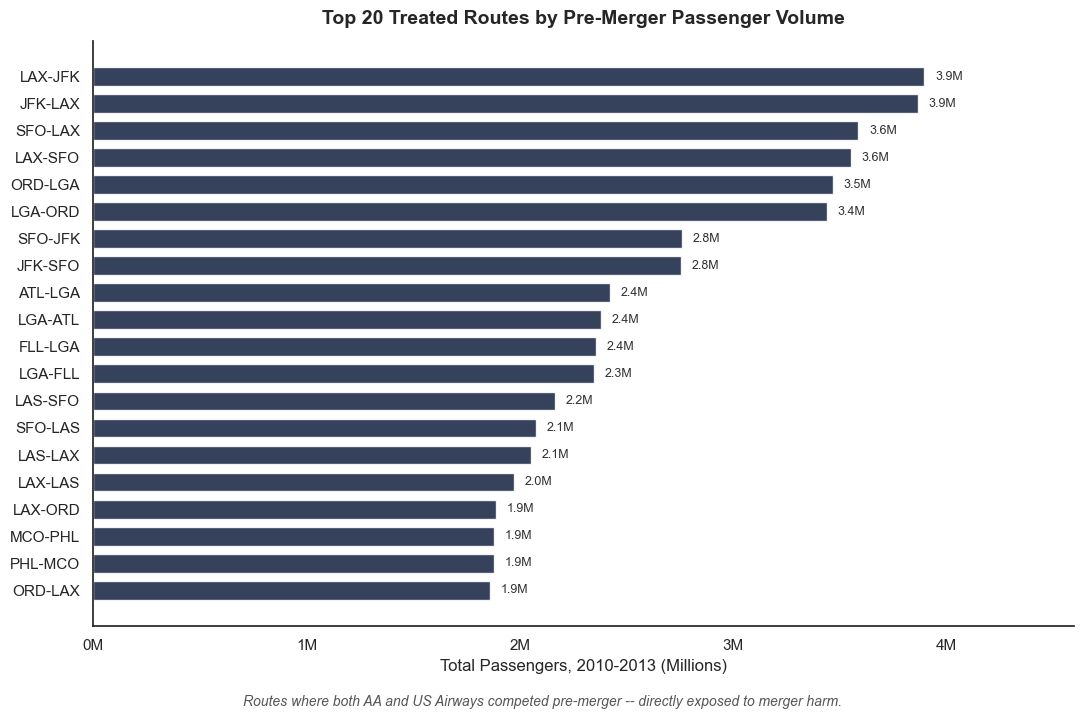

Saved: top_routes_passengers.png


In [3]:
pre_treated = (
    panel[(panel["treated"] == 1) & (panel["post"] == 0)]
    .groupby("route")["total_passengers"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
pre_treated["passengers_M"] = pre_treated["total_passengers"] / 1e6

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    pre_treated["route"][::-1],
    pre_treated["passengers_M"][::-1],
    color=CONTROL_COLOR, edgecolor="white", alpha=0.88, height=0.7,
)
for bar, val in zip(bars, pre_treated["passengers_M"][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}M", va="center", fontsize=9, color="#333")

ax.set_xlabel("Total Passengers, 2010-2013 (Millions)")
ax.set_title("Top 20 Treated Routes by Pre-Merger Passenger Volume", pad=12)
ax.set_xlim(0, pre_treated["passengers_M"].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))

fig.text(0.5, -0.02,
         "Routes where both AA and US Airways competed pre-merger -- directly exposed to merger harm.",
         ha="center", fontsize=10, style="italic", color="#555")

plt.tight_layout()
plt.savefig(FIG_DIR / "top_routes_passengers.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: top_routes_passengers.png")

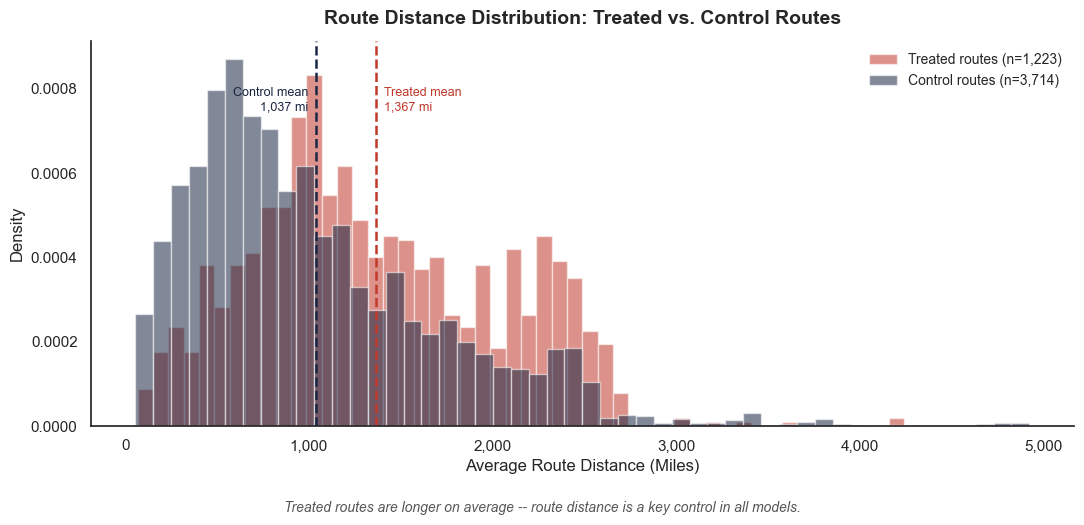

Saved: distance_distribution.png


In [4]:
route_chars = (
    panel[panel["post"] == 0]
    .groupby(["route", "treated"])["avg_distance"]
    .mean().reset_index()
)
treated_dist = route_chars[route_chars["treated"] == 1]["avg_distance"]
control_dist = route_chars[route_chars["treated"] == 0]["avg_distance"]
treated_mean = treated_dist.mean()
control_mean = control_dist.mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(treated_dist, bins=50, color=TREATED_COLOR, alpha=0.55,
        label=f"Treated routes (n={len(treated_dist):,})", density=True)
ax.hist(control_dist, bins=50, color=CONTROL_COLOR, alpha=0.55,
        label=f"Control routes (n={len(control_dist):,})", density=True)

ax.axvline(treated_mean, color=TREATED_COLOR, linestyle="--", linewidth=1.8)
ax.axvline(control_mean, color=CONTROL_COLOR, linestyle="--", linewidth=1.8)

ymax = ax.get_ylim()[1]
ax.text(treated_mean + 40, ymax * 0.88,
        f"Treated mean\n{treated_mean:,.0f} mi",
        color=TREATED_COLOR, fontsize=9, va="top")
ax.text(control_mean - 40, ymax * 0.88,
        f"Control mean\n{control_mean:,.0f} mi",
        color=CONTROL_COLOR, fontsize=9, va="top", ha="right")

ax.set_xlabel("Average Route Distance (Miles)")
ax.set_ylabel("Density")
ax.set_title("Route Distance Distribution: Treated vs. Control Routes", pad=12)
ax.legend(fontsize=10, frameon=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.text(0.5, -0.04,
         "Treated routes are longer on average -- route distance is a key control in all models.",
         ha="center", fontsize=10, style="italic", color="#555")

plt.tight_layout()
plt.savefig(FIG_DIR / "distance_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: distance_distribution.png")

In [5]:
print("Proposal EDA figures complete.")
print(f"Saved to: {FIG_DIR.resolve()}")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name} ({f.stat().st_size/1024:.0f} KB)")
print()
print("Use in proposal slides:")
print("  Slide 3 (EDA): parallel_trends.png + top_routes_passengers.png side by side")
print("  Slide 4 (Modeling): distance_distribution.png motivates distance control")

Proposal EDA figures complete.
Saved to: C:\Users\rohan\OneDrive\Documents\STAT 418\Final Project\docs\figures\proposal
  distance_distribution.png (97 KB)
  parallel_trends.png (199 KB)
  top_routes_passengers.png (141 KB)

Use in proposal slides:
  Slide 3 (EDA): parallel_trends.png + top_routes_passengers.png side by side
  Slide 4 (Modeling): distance_distribution.png motivates distance control
